In [2]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [3]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
    make_animation,
    plot
)
import plotly.express as px
from src.classify import classify_trajectories
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops

In [4]:
model = "bruss"
ds_id = "param_sweep"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df = ds.df
df = expand_json_column(df, "original_point", "op", True)
df = expand_json_column(df, "initial_condition", "ic", True)
df = classify_trajectories(df)
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [52]:
def classify_brusselator_patterns(data_array, alpha):
    """
    Classifies patterns in a series of 2D Brusselator frames as 'labyrinth' or 'dots'.

    The classification is based on the ratio of the largest connected component's
    area to the total image area.

    Args:
        data_array (np.ndarray): A 3D NumPy array of shape (num_traj, height, width)
                                 containing the image data for each trajectory.
                                 Pixel values are expected to be numerical.
        alpha (float): The threshold for classification. If the normalized area
                       of the largest component exceeds alpha, the pattern is
                       classified as 'labyrinth'. Must be between 0.0 and 1.0.

    Returns:
        list: A list of strings, where each string is either 'labyrinth' or 'dots',
              corresponding to the classification of each frame in data_array.

    Raises:
        ValueError: If input arguments are invalid (e.g., wrong data_array shape,
                    invalid alpha value, non-positive image dimensions).
    """
    if not (isinstance(data_array, np.ndarray) and data_array.ndim == 3):
        raise ValueError("Input data_array must be a 3D NumPy array of shape (num_traj, height, width).")
    if not (isinstance(alpha, float) and 0.0 < alpha < 1.0):
        raise ValueError("Alpha threshold must be a float strictly between 0.0 and 1.0.")

    num_traj, height, width = data_array.shape
    if height <= 0 or width <= 0:
        raise ValueError("Image dimensions (height, width) must be positive.")
        
    classifications = []
    total_area = float(height * width) 

    for i in range(num_traj):
        frame = data_array[i]
        A_max = 0.0
        if frame.std() < 0.05:
            classifications.append("const")
            continue
        if frame.min() == frame.max():
            binary_image = np.zeros_like(frame, dtype=bool)
        else:
            try:
                thresh = threshold_otsu(frame)
                binary_image = frame > thresh
            except ValueError:
                binary_image = np.zeros_like(frame, dtype=bool)

        if np.any(binary_image): 
            labeled_image = label(binary_image, connectivity=2, background=0)
            props = regionprops(labeled_image)
            
            if props: 
                component_areas = [prop.area for prop in props]
                A_max = np.max(component_areas)
        
        R_lc = A_max / total_area
            
        if R_lc > alpha:
            classifications.append("labyrinth")
        else:
            classifications.append("dots")

    return classifications

In [54]:
df['class'] = classify_brusselator_patterns(result, 0.02)

In [45]:
df['class'].unique()

array(['dots', 'labyrinth'], dtype=object)

7333


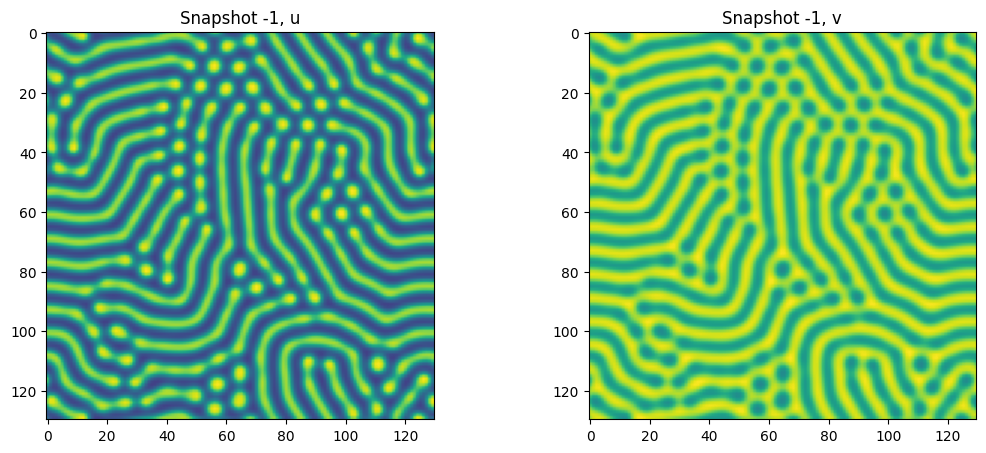

10360


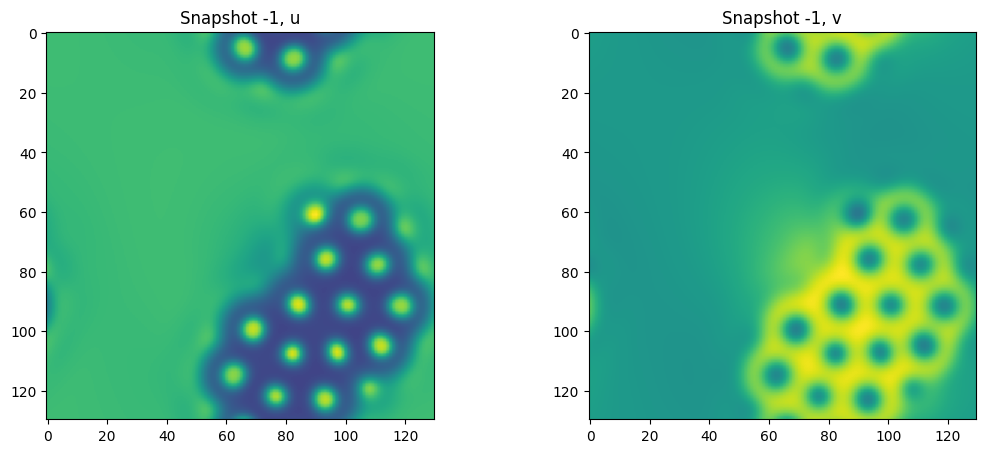

6760


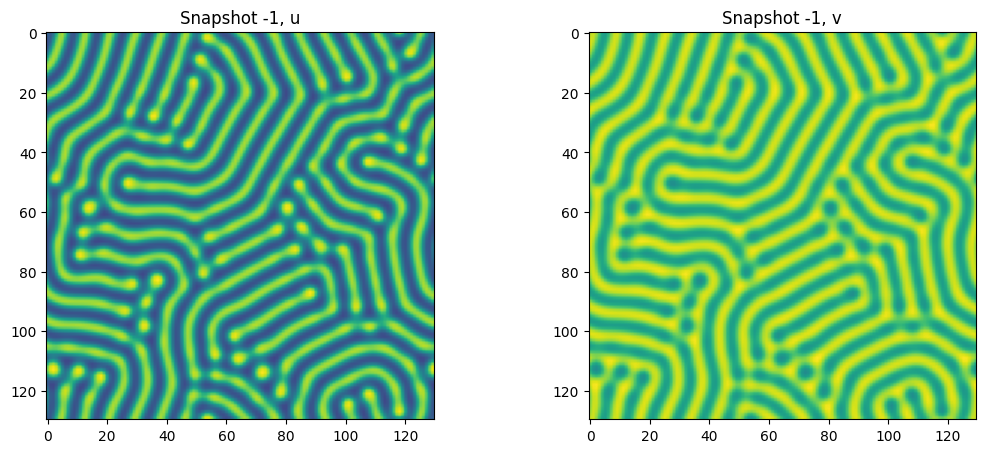

7085


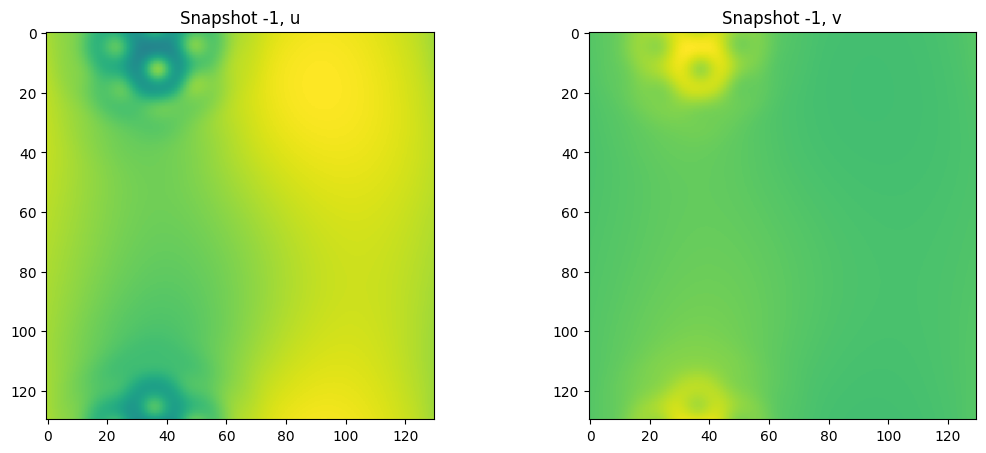

965


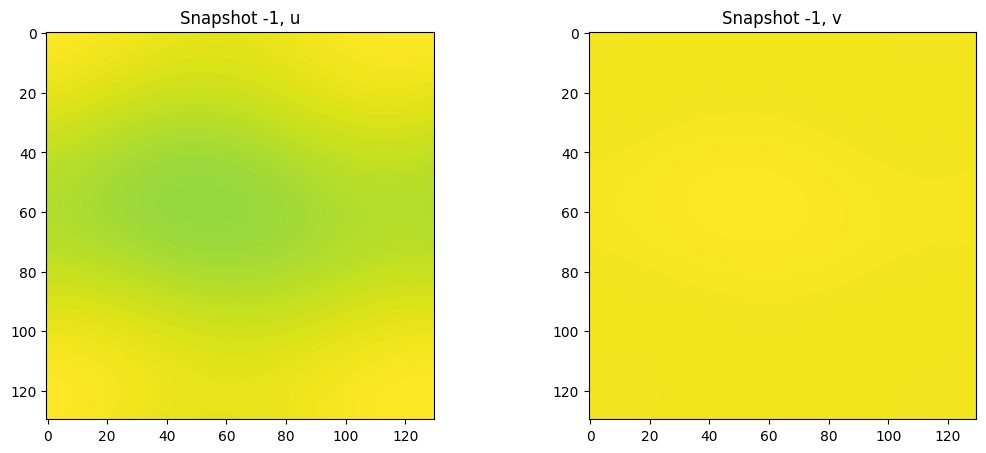

In [7]:
df_sub = df[df["pattern_class"] == "labyrinth"]
for i, row in df_sub.sample(5).iterrows():
    print(i)
    d = ds.get_data(i)
    plot(d, 0, np.max(d))
    plt.show()

In [23]:
df['is_lab'] = 0
df.loc[(df.pattern_class == "labyrinth") & (df.category == "INT"), 'is_lab'] = 1
fig = px.scatter_3d(
    df,
    x="A",
    y="ratio_b_a",
    z="ratio_d",
    color="is_lab",
    opacity=0.5,
    hover_data={"idx": True},
)
fig.update_traces(marker_size=5)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

728


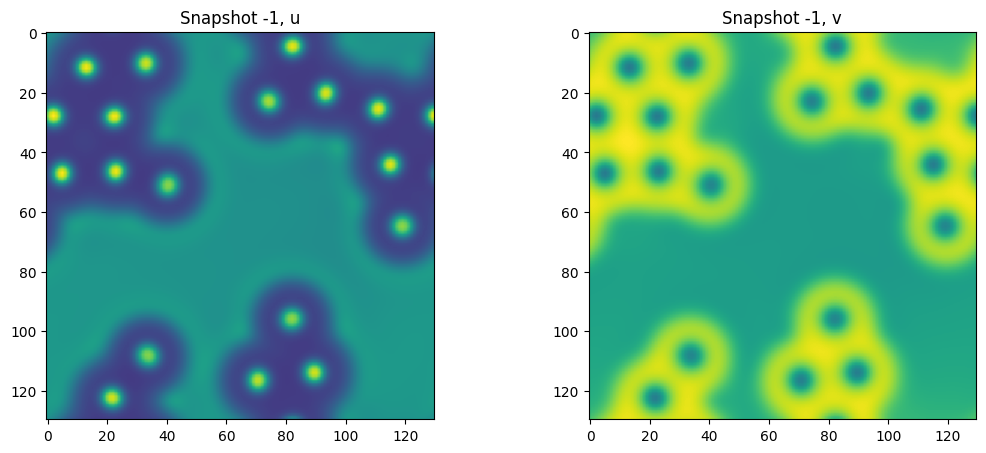

965


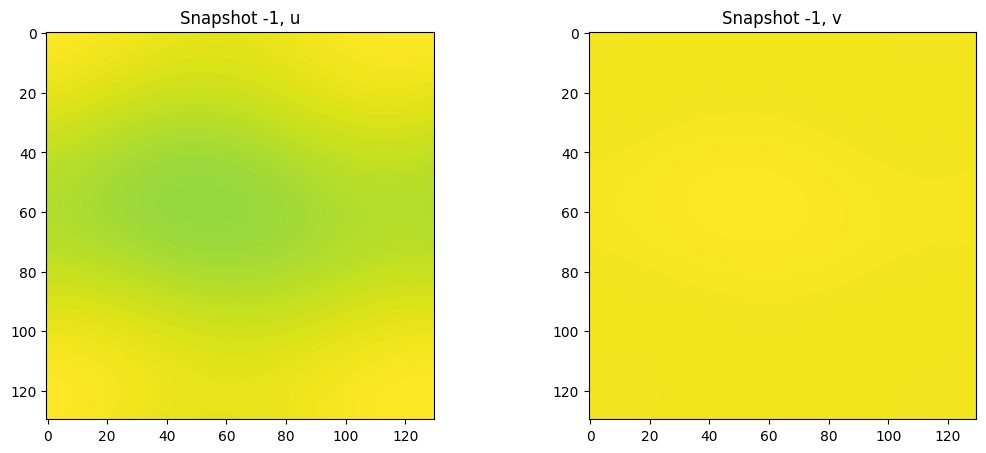

1153


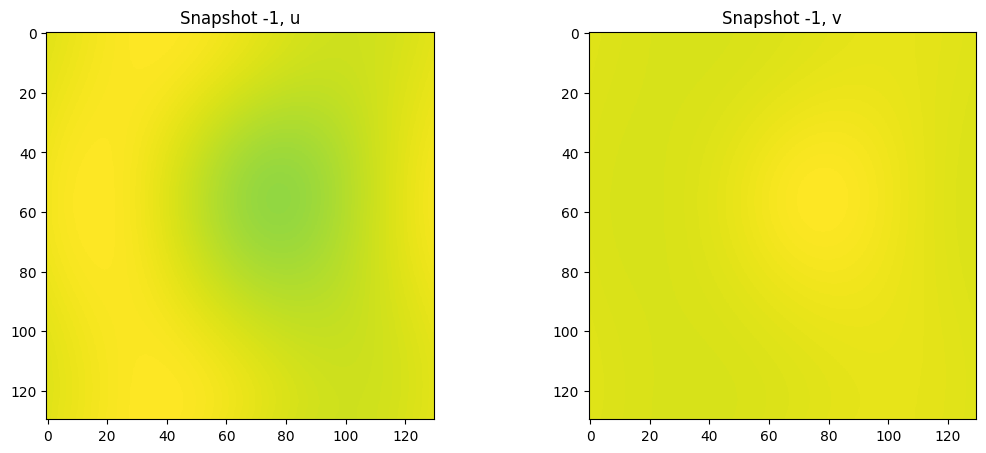

2867


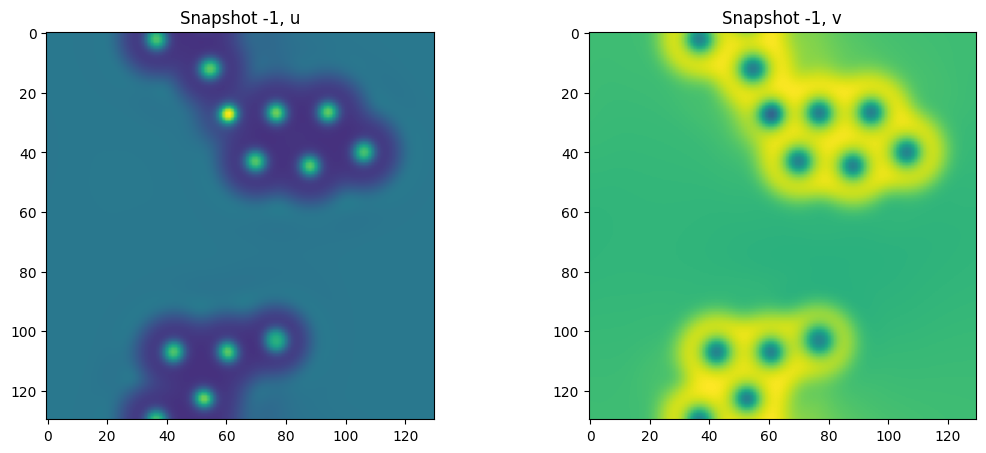

3358


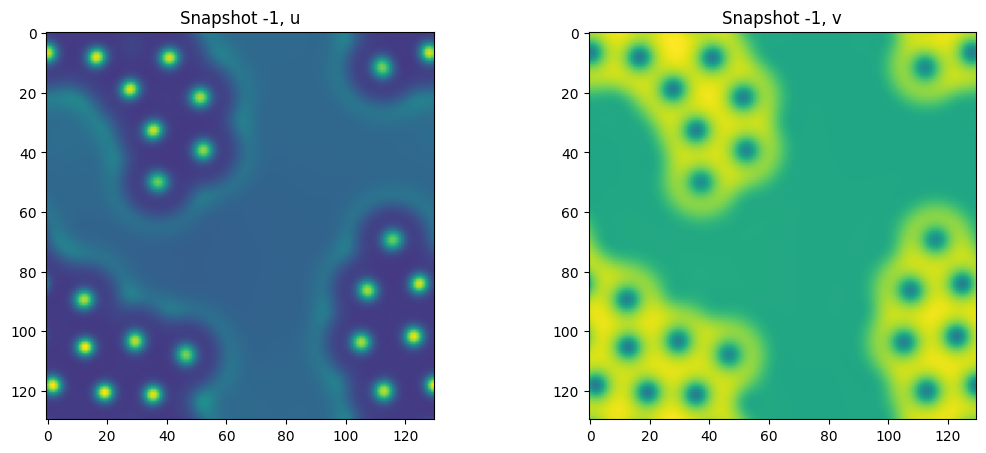

7085


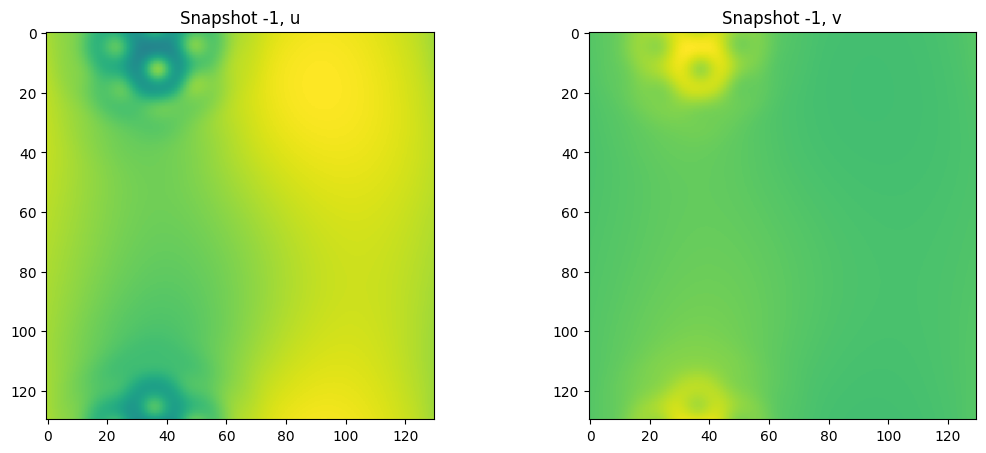

7261


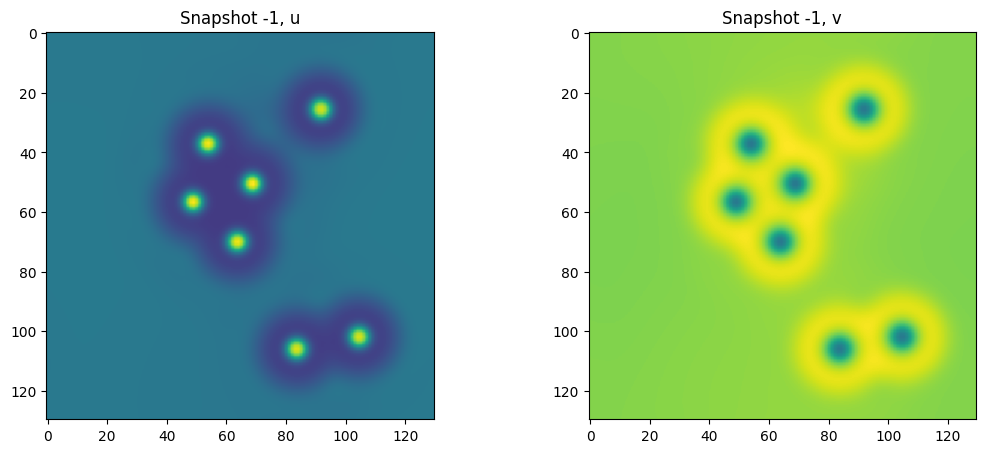

7777


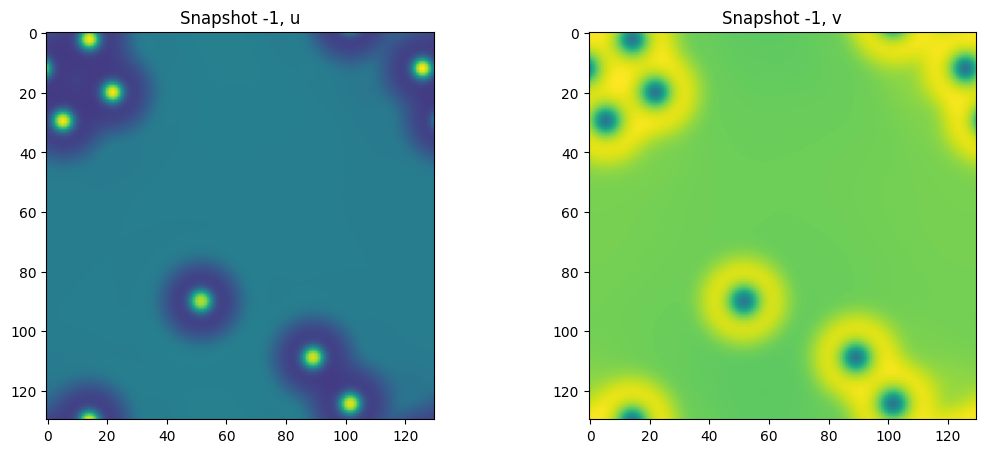

8145


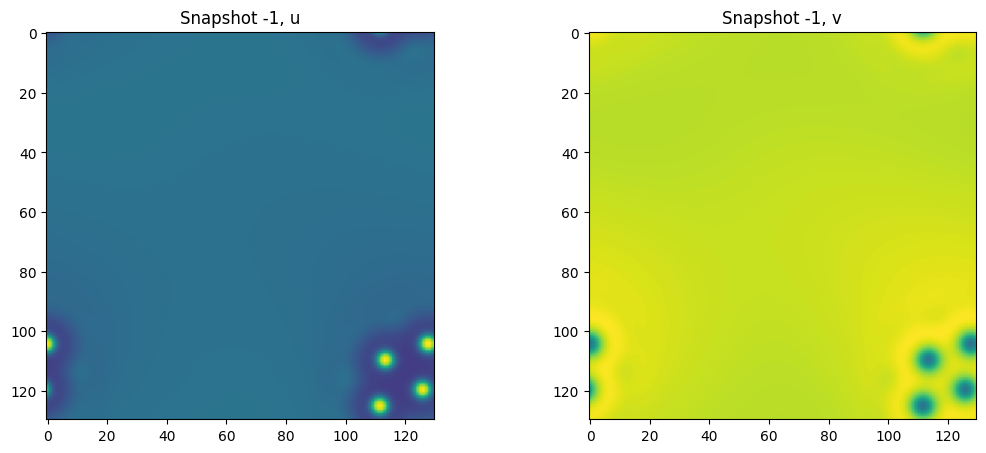

10360


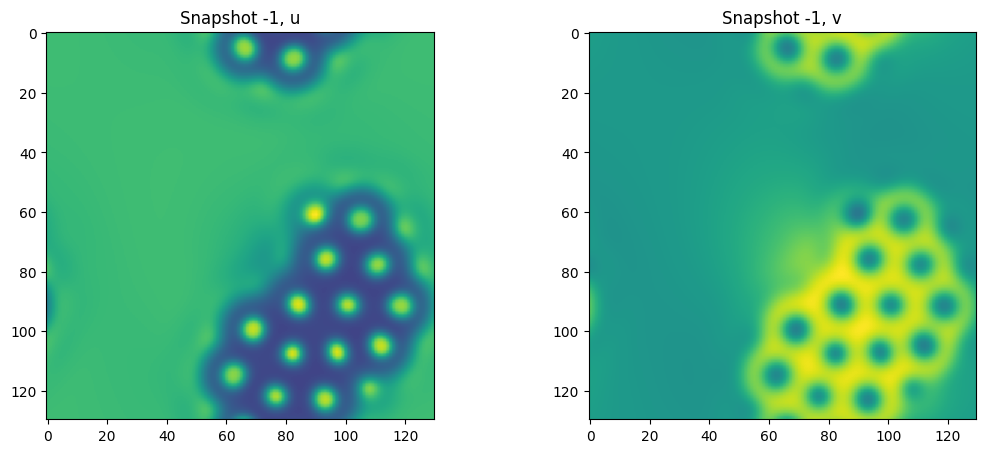

In [18]:
df_sub = df[(df.pattern_class == "labyrinth") & (df.category == "OSC")]
for i, row in df_sub.iterrows():
    print(i)
    d = ds.get_data(i)
    plot(d, 0, np.max(d))
    plt.show()

In [12]:
df.value_counts("pca_label")

pca_label
2    143
0    126
1    116
Name: count, dtype: int64

264


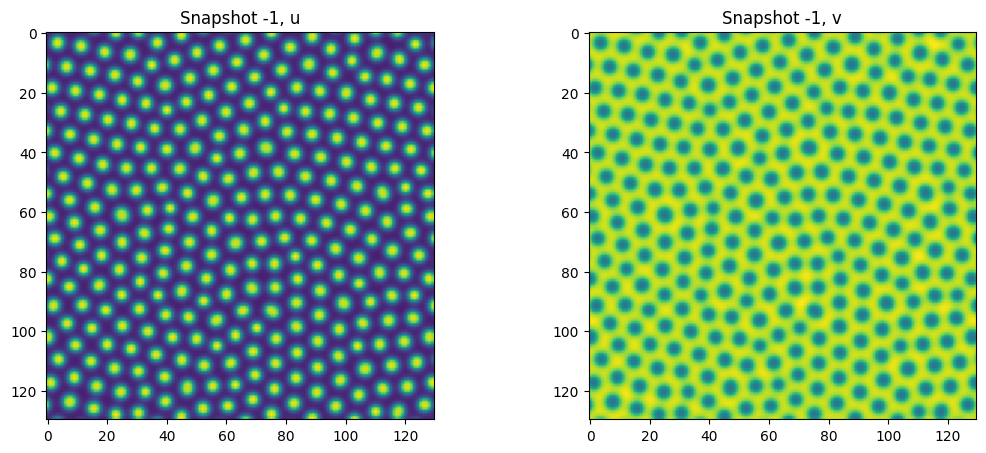

351


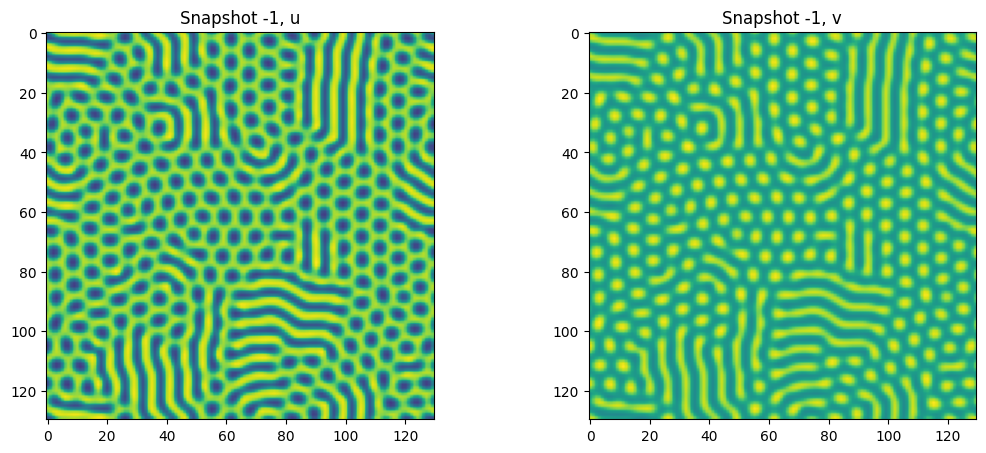

121


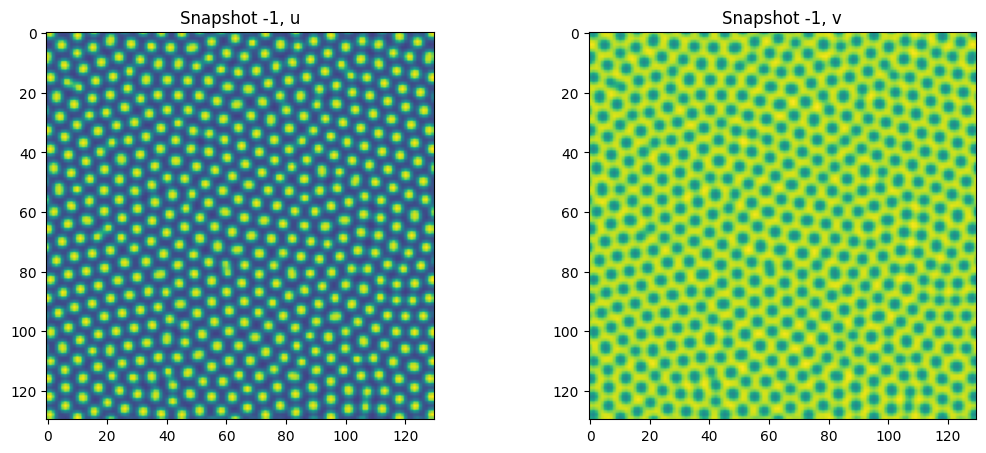

57


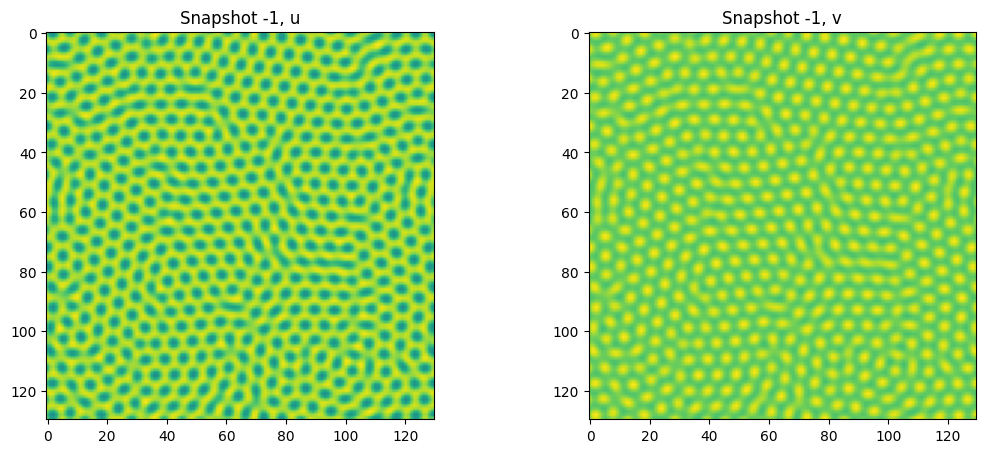

236


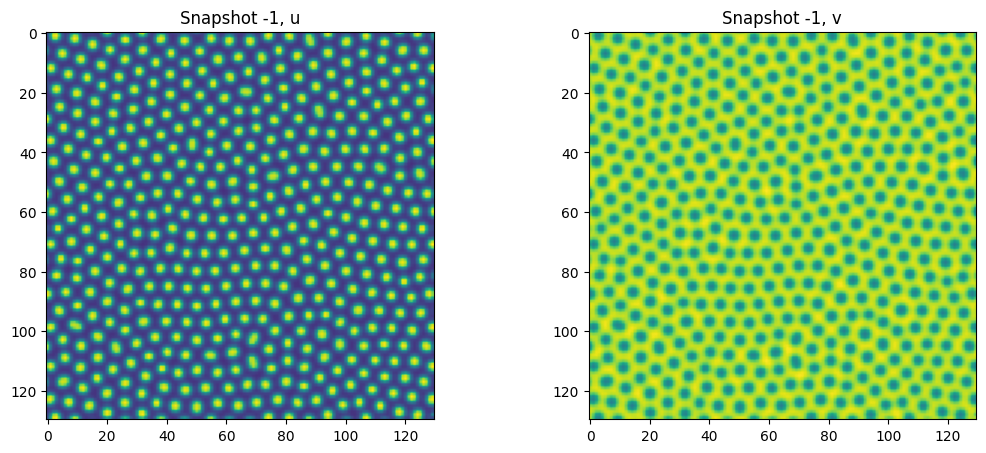

In [16]:
df_sub = df[df.pca_label == 2]
for i, row in df_sub.sample(5).iterrows():
    print(i)
    d = ds.get_data(i)
    plot(d, 0, np.max(d))
    plt.show()

In [24]:
i = 10700
d = ds.get_data(i)
make_animation(d, str(i), ".")

MovieWriter ffmpeg unavailable; using Pillow instead.
